In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import f_oneway
import time
from itertools import combinations

from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score

import mlacca_functions as mlcf

# hide the "y_pred contains classes not in y_true" UserWarning from sklearn as it is expected when using different definitions
from warnings import filterwarnings
filterwarnings("ignore",module="sklearn",category=UserWarning)

In [2]:
df_path = 'data\\csv_files\\new_vk_areas_df.csv'

comparison_plots_output_folder = 'data\\plots\\comparisons'

weighted = True
show_title = False

In [3]:
df = pd.read_csv(df_path)

In [4]:
# Functions

def test_model_accuracy(model,X,y,repeats=50, classifier_name='[DEFAULT]', title=None,
                        xlabel=None,ylabel=None,colors_dict=None):

    accuracies = []

    for i in range(repeats):
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X, y,random_state=None)

        fitted_model = model.fit(X_rdm_train, y_rdm_train, sample_weight=weights_rdm_train if weighted else None)

        accuracies.append(balanced_accuracy_score(y_true = y_rdm_test,
                                                y_pred = fitted_model.predict(X_rdm_test),
                                                sample_weight=weights_rdm_test if weighted else None,
                                                ))

        if accuracies[i] == np.max(accuracies):
            max_model = fitted_model
            X_rdm_train_best = X_rdm_train
            y_rdm_train_best = y_rdm_train

    print(f'''Average accuracy of the {classifier_name} classifier trained on {len(X_rdm_train)} samples (run {repeats} times): {np.mean(accuracies)} +/- {np.std(accuracies)}
Max accuracy: {np.max(accuracies)}
Min accuracy: {np.min(accuracies)}
Random Accuracy: {1/len(np.unique(y_rdm_train))}''')

    if np.shape(X)[1] == 2:
        mlcf.draw_decision_boundary_plot(max_model,
                                    X_rdm_train_best,
                                    categories=np.unique(y_rdm_train_best),
                                    xlabel=xlabel,
                                    ylabel=ylabel,
                                    colors_dict=colors_dict,
                                    title=title
                                    )


def fitting_runtime(iterations:int,model,X,y,weights) -> float:

    times = []

    for i in range(iterations):
        start_time = time.time()
        fit = model.fit(X, y, sample_weight=weights)
        runtime = time.time() - start_time

        times.append(runtime)

    return sum(times)/iterations


def molecclass(df:pd.DataFrame,areas:dict,dims=['O/C','H/C','N/C']) ->  np.ndarray:

    assignments = ['unassigned'] * len(df)

    for i in df[dims].index:
        ratios = df[dims].loc[i]

        for a in areas:
            counter = 0

            for d in dims:
                if ratios[d] >= np.min(areas[a][d]) and ratios[d] <= np.max(areas[a][d]):
                    counter += 1
        
            if counter == len(dims):
                assignments[i] = a
                break
    
    assignments = np.array(assignments)
    assignments[np.where(assignments == 'peptide1')] = 'peptide'
    assignments[np.where(assignments == 'peptide2')] = 'peptide'

    return assignments


def draw_violinplot(data_dict, ylabel, title=None, savepath=None, colours=[],hline=None,
                    xlabel_rotation=45,ha='right',figsize=(6.4, 4.8)):

    labels = list(data_dict.keys())
    data = list(data_dict.values())

    fig, ax = plt.subplots(figsize=figsize)

    parts = ax.violinplot(data,
                          showmeans=False, showmedians=False,
                          showextrema=False)

    if len(colours)>0:
        if len(colours)==1:
            colours = colours * len(labels)
        assert len(colours)==len(labels), "Number of colours must match number of violin plots"
        for pc,c in zip(parts['bodies'],colours):
            pc.set_facecolor(c)
            pc.set_edgecolor('black')
            pc.set_alpha(1)

    quartile1, medians, quartile3 = np.percentile(np.array(data), [25, 50, 75], axis=1)

    inds = np.arange(1, len(medians) + 1)
    ax.scatter(inds, medians, marker='o', color='white', s=30, zorder=3, edgecolors='k')
    ax.vlines(inds, quartile1, quartile3, color='k', linestyle='-', lw=5)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(np.arange(1,len(labels)+1), labels, rotation=xlabel_rotation, ha=ha, fontsize=12)

    if hline:
        if type(hline) in [list, tuple]:
            for hl in hline:
                ax.axhline(y=hl, color='r', linestyle='--', lw=1)
        else:
            ax.axhline(y=hline, color='r', linestyle='--', lw=1)

    if title: ax.set_title(title, fontsize=14)
    if savepath: fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def correlation_matrix(data_dict, threshold=0.05, savepath=None, title=None,
                       colours=['tab:orange','tab:blue']):

    # first colour for p <= threshold (significant difference),
    # second for p > threshold (not significant difference)

    labels = list(data_dict.keys())

    p_dict = {}
    for comb in list(combinations(labels,2)):
        p_dict[f'{comb[0]},{comb[1]}'] = f_oneway(*[data_dict[comb[0]],data_dict[comb[1]]],nan_policy='omit')[1]

    # draw a binary correlation matrix plot of the p values and colour only the values < 0.05
    p_matrix = pd.DataFrame(np.ones((len(labels),len(labels))), index=labels, columns=labels)
    p_matrix[p_matrix == 1] = np.nan
    for comb in list(combinations(labels,2)):
        p_value = p_dict[f'{comb[0]},{comb[1]}']
        p_matrix.loc[comb[0], comb[1]] = np.nan
        p_matrix.loc[comb[1], comb[0]] = p_value

    p_matrix[(p_matrix > threshold)&(p_matrix.notna())] = 1
    p_matrix[(p_matrix <= threshold)&(p_matrix.notna())] = 0

    fig, ax = plt.subplots()

    cmap = mpl.colors.ListedColormap(colours)

    cax = ax.matshow(p_matrix, cmap=cmap)

    for label, colour in zip([f'$p\\leq{threshold}$', f'$p>{threshold}$'], colours):
        ax.scatter([], [], c=colour, label=label,marker='s',s=100)

    ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)

    ax.set_xticks(np.arange(len(labels)-1), labels[:-1], rotation=45,horizontalalignment='right')
    ax.set_yticks(np.arange(1,len(labels)), labels[1:])
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlim(-0.5, len(labels)-1.5)
    ax.set_ylim(len(labels)-0.5, 0.5)

    if title: ax.set_title(title, fontsize=14)
    if savepath: fig.savefig(savepath, dpi=600, facecolor='#fff', bbox_inches='tight')

    return fig, ax


def set_y_ticks(data_dict,ax,major_ticks_interval=0.1,minor_ticks_interval=0.05,rounding=2):
    ylim = (np.round(np.floor(10**rounding*np.min(list(data_dict.values())))/10**rounding,rounding)-10**-rounding, 1)
    ax.set_ylim(ylim)
    
    ax.set_yticks(np.arange(np.round(np.floor(1e2*ylim[0])/1e2,1),ylim[1]+0.01, major_ticks_interval))

    ax.tick_params(axis='y', which='minor')
    ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(minor_ticks_interval))

In [5]:
columns_2d = ['O/C','H/C']#, 'N/C', 'S/C', 'P/C']
X_2d = df[columns_2d].to_numpy()

columns_3d = ['O/C','H/C','N/C']
X_3d = df[columns_3d].to_numpy()

y = df['category'].to_numpy()
weights = df['weights'].to_numpy() if weighted else None

multiclass_colors=[mlcf.vk_region_colours[cat] for cat in np.unique(y)]

In [6]:
# comparison of these models with literature models

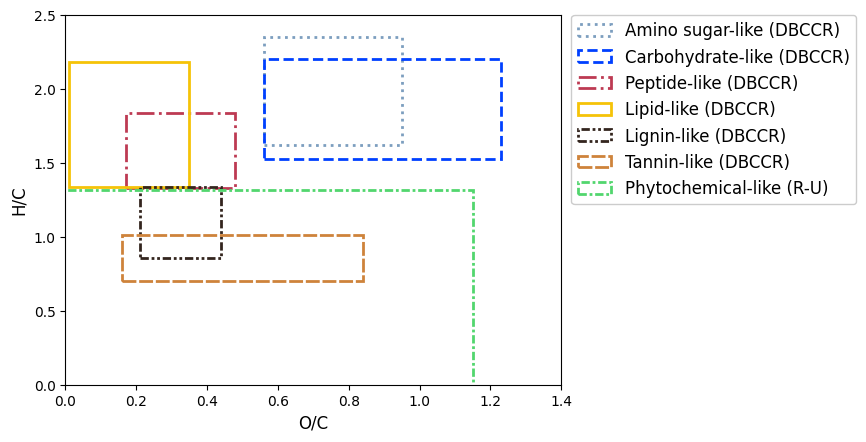

In [7]:
# show overlap of phytochemical and lignin/tannin definitions used

def rectangle(ax,p1,p2,**kwargs):
    h = p2[1]-p2[0]
    w = p1[1]-p1[0]

    facecolor = kwargs.get('facecolor',None)
    edgecolor = kwargs.get('edgecolor',None)
    alpha = kwargs.get('alpha',None)
    label = kwargs.get('label',None)
    lw = kwargs.get('lw',None)
    ls = kwargs.get('ls',None)

    rect=plt.Rectangle((p1[0],p2[0]),w,h,facecolor=facecolor, alpha=alpha, edgecolor=edgecolor,label=label,lw=lw,ls=ls)
    ax.add_patch(rect)

fig, ax = plt.subplots()

areas_compare = {x:mlcf.laszakovits_mackay_areas[x] for x in mlcf.laszakovits_mackay_areas}
areas_compare['phytochemical'] = mlcf.rivasubach_areas['phytochemical']

ls_dict ={
    'lipid': 'solid', 
    'peptide': 'dashdot',

    'carbohydrate': 'dashed',
    'amino_sugar': 'dotted', 
    
    'lignin': (0, (3, 1, 1, 1, 1, 1)), 
    'tannin': (0, (5, 1)),
    'phytochemical': (0, (3, 1, 1, 1))
}

for a in areas_compare:
    # i = keys.index(a)
    label = f'{a.capitalize().replace('_',' ')}-like'
    
    label += ' (DBCCR)' if a in mlcf.laszakovits_mackay_areas else ' (R-U)'

    rectangle(ax,areas_compare[a]['O/C'],areas_compare[a]['H/C'],
              facecolor='none',edgecolor=mlcf.vk_region_colours[a],label=label,ls=ls_dict[a],lw=2)#,ls='--')

ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
ax.set_xlim(0,1.4)
ax.set_ylim(0,2.5)
ax.set_xlabel('O/C',fontsize=12)
ax.set_ylabel('H/C',fontsize=12)
fig.savefig('data\\plots\\van_krevelens\\l&m_and_phytochemical.png',dpi=600, facecolor = '#fff', bbox_inches='tight')

In [8]:
rivas_ubach_adj_cat = df['category'].copy().to_numpy()

for cat in ['lignin','tannin']:
    rivas_ubach_adj_cat[np.where(rivas_ubach_adj_cat == cat)] = 'phytochemical'

rivas_ubach_class_weights = compute_class_weight('balanced', classes=np.unique(rivas_ubach_adj_cat), y=rivas_ubach_adj_cat)
rivas_ubach_class_weights_dict = {cls: weight for cls, weight in zip(np.unique(rivas_ubach_adj_cat), rivas_ubach_class_weights)}
rivas_ubach_weights = [rivas_ubach_class_weights_dict[cat] for cat in rivas_ubach_adj_cat]

In [9]:
# test the model accuracies using the same slices of the overall dataset and plot boxplots and do ANOVA on the results

clf_models = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'SVM (poly) (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d)),
    'SVM (RBF) (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d)),
}

clf_models_unweighted = {x.replace('(W)','(U)'):clf_models[x] for x in clf_models}
clf_models_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d)

lit_models = {
    'DBCCR': mlcf.laszakovits_mackay_areas,
    'Adjusted MSCC': mlcf.ru_lm_areas,
}

phyto_clf_models = {f'{x} (R-U)' : clf_models[x] for x in clf_models}

phyto_clf_models_unweighted = {f'{x} (R-U)' : clf_models_unweighted[x] for x in clf_models_unweighted}

phyto_lit_model = {'MSCC': mlcf.rivasubach_areas,}

models_list = list(lit_models.keys()) + list(clf_models_unweighted.keys()) + list(clf_models.keys()) +\
              list(phyto_lit_model.keys()) + list(phyto_clf_models_unweighted.keys()) + list(phyto_clf_models.keys())

In [10]:
accuracies_dict = {name: [] for name in models_list}
balanced_accuracies_dict = {name: [] for name in models_list}
zero_rule_acc = []

repeats = 40

iteration_dict = {'non_r-u':{'definition':y,'modeltypes':[clf_models, clf_models_unweighted, lit_models]},
                  'r-u':{'definition':rivas_ubach_adj_cat,'modeltypes':[phyto_clf_models, phyto_clf_models_unweighted, phyto_lit_model]}}

for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')
    
    for definition_type in iteration_dict:
        X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
        weights_rdm_train, weights_rdm_test = mlcf.train_test(X_3d, iteration_dict[definition_type]['definition'], random_state=None)

        if definition_type == 'non_r-u':
            zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test==cat)[0]) for cat in np.unique(y_rdm_test)])]
            zero_rule_acc.append(accuracy_score(y_true=y_rdm_test,
                                                y_pred=[zero_rule_class]*len(y_rdm_test),
                                                normalize=True))

        for modeltype in iteration_dict[definition_type]['modeltypes']:

            for model in modeltype:
                
                print(f'{n+1}/{repeats}\tTesting model: {model}')

                sample_weight = dict(sample_weight=weights_rdm_train) if weighted and modeltype == clf_models else None

                fit_args = dict(X=X_rdm_train, y=y_rdm_train)
                if weighted and modeltype in [clf_models,phyto_clf_models]: fit_args['sample_weight'] = weights_rdm_train

                clf = modeltype[model].fit(**fit_args) if modeltype not in [lit_models,phyto_lit_model] else None

                y_pred = clf.predict(X_rdm_test) if modeltype not in [lit_models,phyto_lit_model]\
                         else molecclass(pd.DataFrame(X_rdm_test, columns=columns_3d), areas=lit_models[model] if modeltype == lit_models else phyto_lit_model[model],
                                         dims=columns_3d if 'DBCCR' not in model else columns_2d)

                for accuracy_type in [[accuracy_score, dict(normalize=True), accuracies_dict],
                                      [balanced_accuracy_score, dict(sample_weight=weights_rdm_test if weighted else None), balanced_accuracies_dict]]:
                    
                    acc = accuracy_type[0](y_true=y_rdm_test,
                                           y_pred=y_pred,
                                           **accuracy_type[1])
                    accuracy_type[2][model].append(acc)

                print(f'\t\taccuracy: {accuracies_dict[model][-1]}, balanced accuracy: {balanced_accuracies_dict[model][-1]}')


Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 0.7748123436196831, balanced accuracy: 0.8727445260053953
1/40	Testing model: SVM (poly) (W)
		accuracy: 0.8882402001668057, balanced accuracy: 0.8972567287784677
1/40	Testing model: SVM (RBF) (W)
		accuracy: 0.8974145120934112, balanced accuracy: 0.9066754501537108
1/40	Testing model: GNB (U)
		accuracy: 0.9115929941618015, balanced accuracy: 0.5743069655188064
1/40	Testing model: SVM (poly) (U)
		accuracy: 0.9065888240200167, balanced accuracy: 0.5807865892972276
1/40	Testing model: SVM (RBF) (U)
		accuracy: 0.9115929941618015, balanced accuracy: 0.5903556511327094
1/40	Testing model: KNN
		accuracy: 0.9624687239366139, balanced accuracy: 0.8902613087395695
1/40	Testing model: DBCCR
		accuracy: 0.5988323603002502, balanced accuracy: 0.6628949955036908
1/40	Testing model: Adjusted MSCC
		accuracy: 0.8857381150959133, balanced accuracy: 0.7542396009787312
1/40	Testing model: GNB (W) (R-U)
		accuracy: 0.801501251042

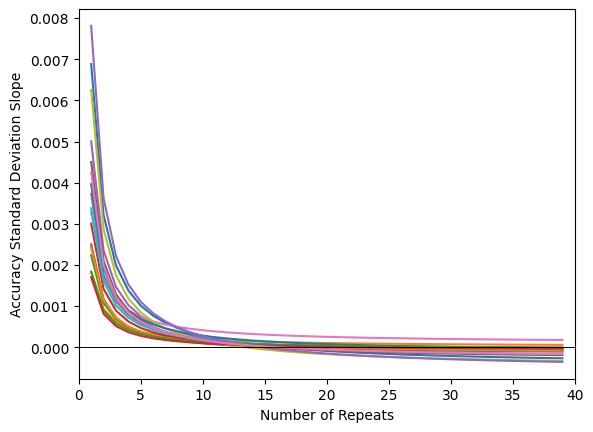

In [ ]:
# Plot the derivative of std vs number of repeats.
# Only save the plot of this cell after running the accuracy tests cell for a large number of repeats (e.g. 200) to see where the std stabilizes.
# This is to help decide on a reasonable number of repeats for future tests.

SAVE = True

def fitting_func(x, a, b, c):
    return a * (b * x)**(-1) + c

curves_list = []

for model in models_list:
    fig, ax = plt.subplots()

    n_of_times = range(1,len(accuracies_dict[model])+1)

    step_wise_stds = [np.std(accuracies_dict[model][:i]) for i in n_of_times]

    y_axis = np.diff(step_wise_stds)/np.diff(n_of_times)

    ax.scatter(n_of_times[:-1], y_axis,marker='.', alpha=0.7)

    popt, pcov = curve_fit(fitting_func, n_of_times[:-1], y_axis)
    curves_list.append(fitting_func(np.array(n_of_times[:-1]), *popt))
    ax.plot(n_of_times[:-1], curves_list[-1], 'r--', label=f'${popt[0]}*\\frac{{1}}{{{popt[1]}}}*x + {popt[2]}$')

    if show_title:
        ax.set_title(f'{model}\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
    ax.set_xlabel('Number of Repeats')
    ax.set_ylabel('Accuracy Standard Deviation Slope')
    ax.set_xlim(0, len(accuracies_dict[model]))

    ax.axhline(0,lw=.7,c='k')

    if SAVE:
        fig.savefig(f'{comparison_plots_output_folder}\\accuracy_std_vs_repeats\\accuracy_std_slope_vs_repeats_{model.replace(' ','_')}.png', dpi=600, facecolor='#fff', bbox_inches='tight')

    plt.close()

fig, ax = plt.subplots()
for curve in curves_list:
    ax.plot(range(1,len(accuracies_dict[model])), curve)
if show_title:
    ax.set_title(f'All Models\nAccuracy Standard Deviation Slope vs Number of Repeats', fontsize=14)
ax.set_xlabel('Number of Repeats',fontsize=12)
ax.set_ylabel('Accuracy Standard Deviation Slope',fontsize=12)
ax.set_xlim(0, len(accuracies_dict[model]))
ax.axhline(0,lw=.7,c='k')
if SAVE:
    fig.savefig(f'{comparison_plots_output_folder}\\accuracy_std_vs_repeats\\accuracy_std_slope_vs_repeats_all_models.png', dpi=600, facecolor='#fff', bbox_inches='tight')

In [12]:
# adjust accuracies_dict values by the chance of random guessing
chance_balanced_accuracies_dict = {}

for key in balanced_accuracies_dict:
    number_of_categories = len(np.unique(y)) if key not in list(phyto_lit_model.keys()) + list(phyto_clf_models.keys()) else len(np.unique(rivas_ubach_adj_cat))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict[key] ]

In [13]:
comparison_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in models_list],
    'mean_accuracy':[np.mean(accuracies_dict[model]) for model in models_list],
    'std_accuracy':[np.std(accuracies_dict[model]) for model in models_list],
    'median_accuracy':[np.median(accuracies_dict[model]) for model in models_list],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict[model]) for model in models_list],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict[model]) for model in models_list],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict[model]) for model in models_list],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict[model]) for model in models_list],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict[model]) for model in models_list],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict[model]) for model in models_list],
})

comparison_df.to_csv('data\\csv_files\\model_performance_comparison.csv', index=False)

In [14]:
# comparison_df

In [15]:
# boxplot_colors = []
boxplot_colors_dict = {'Literature Models':'moccasin',
                       'Unweighted Supervised\nClassifier Models':'lightcoral',
                       'Weighted Supervised\nClassifier Models':'skyblue',}
zero_rule_colour = 'grey'

def model_colour(model):
    if model in clf_models or model in phyto_clf_models:
        return boxplot_colors_dict['Weighted Supervised\nClassifier Models']
    elif model in lit_models or model in phyto_lit_model:
        return boxplot_colors_dict['Literature Models']
    elif model in clf_models_unweighted or model in phyto_clf_models_unweighted:
        return boxplot_colors_dict['Unweighted Supervised\nClassifier Models']
    else: return zero_rule_colour

plot_type = {'boxplot':mlcf.draw_boxplot,
             'violinplot':draw_violinplot}

data_dict = {'raw':accuracies_dict,
             'balanced':balanced_accuracies_dict,
             'chance':chance_balanced_accuracies_dict}

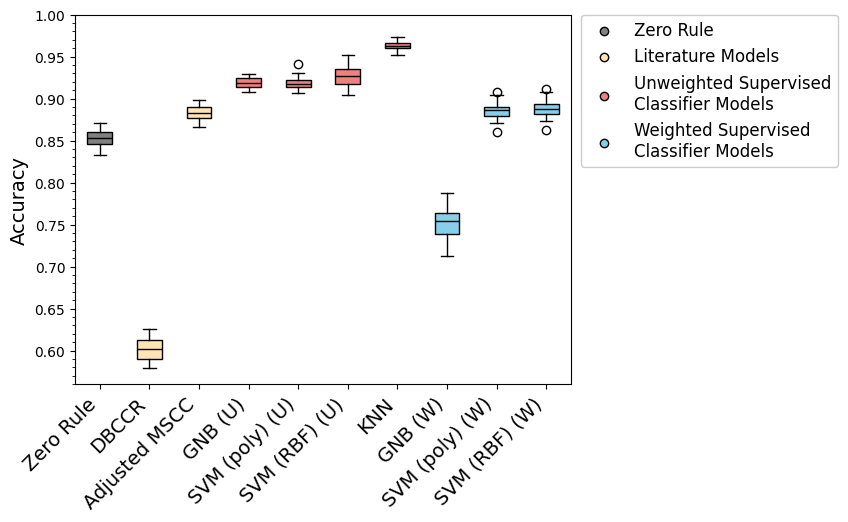

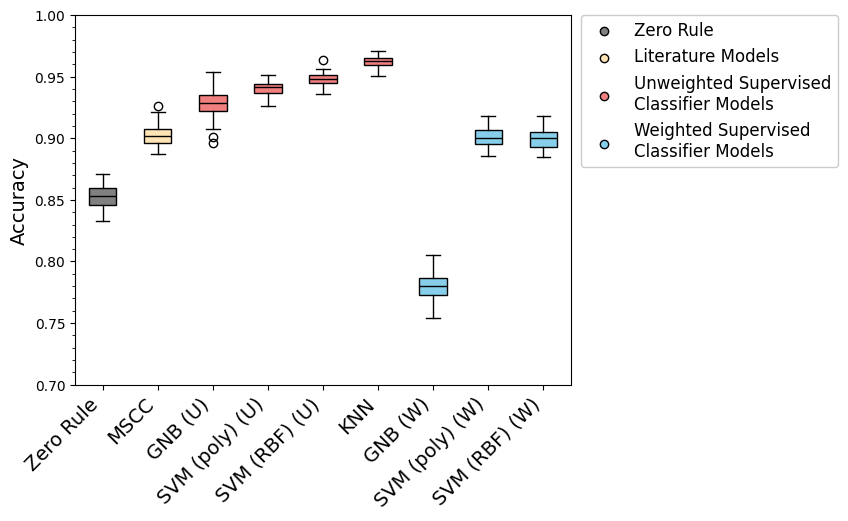

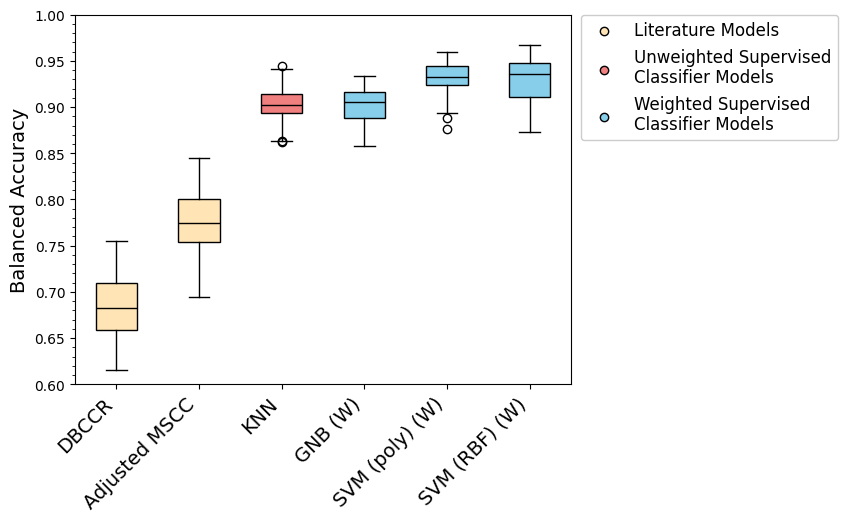

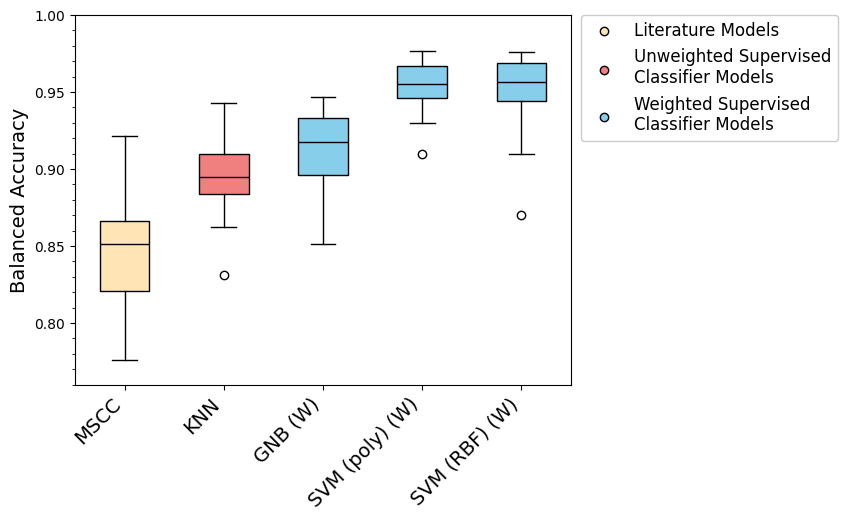

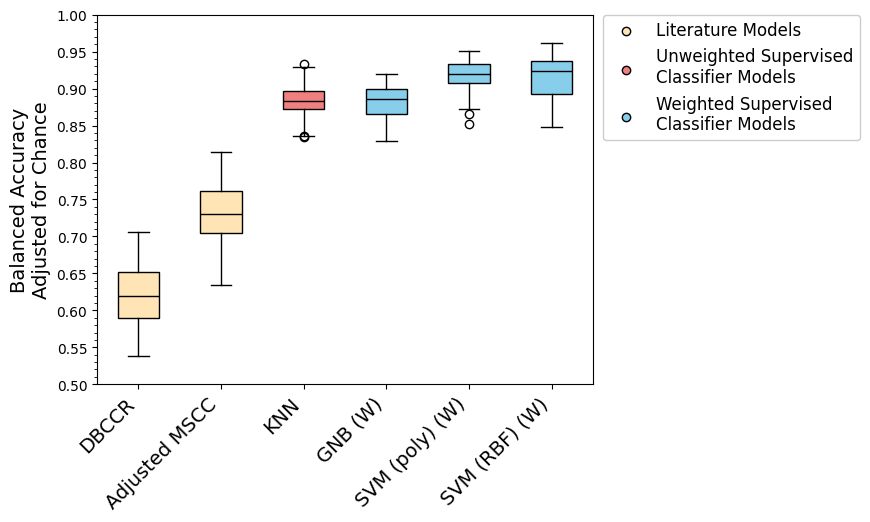

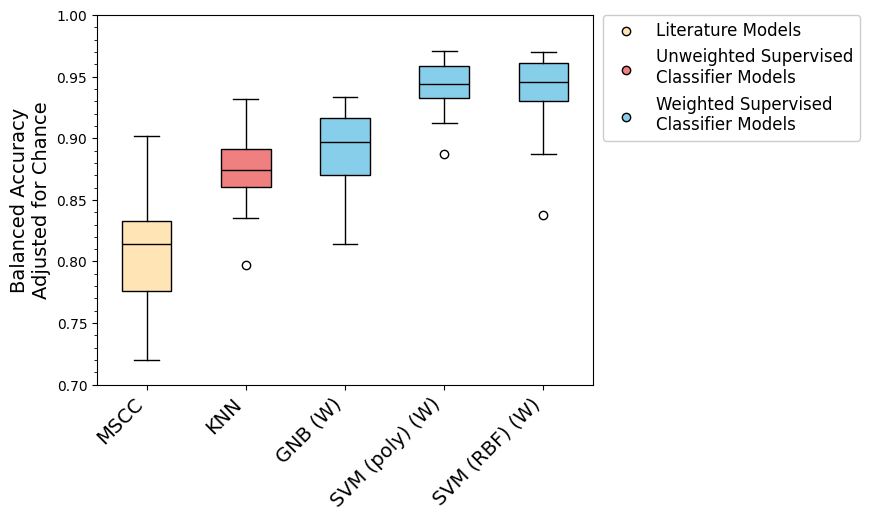

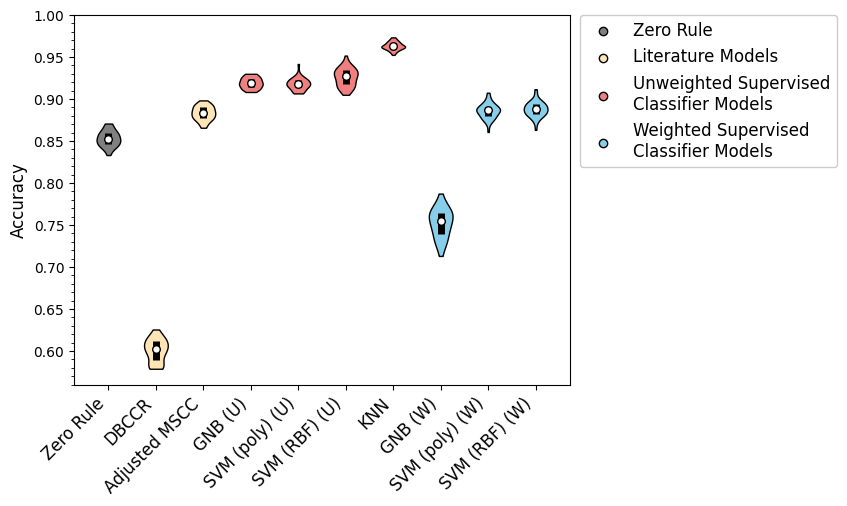

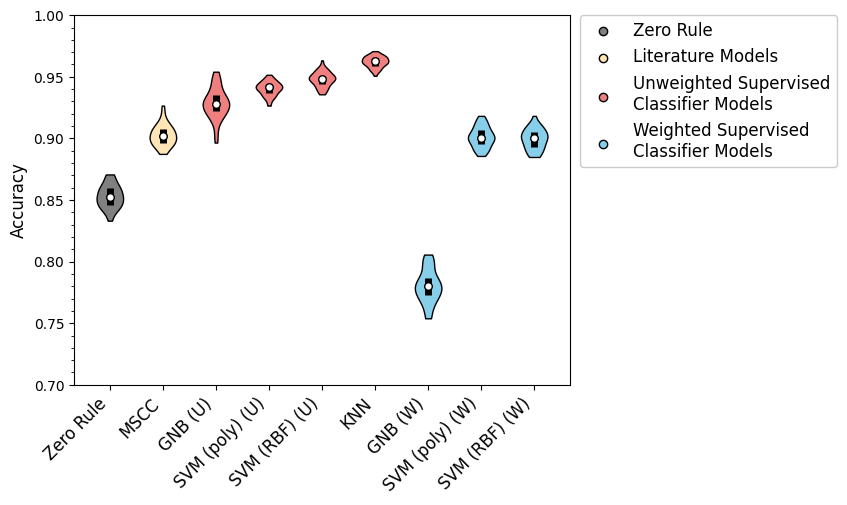

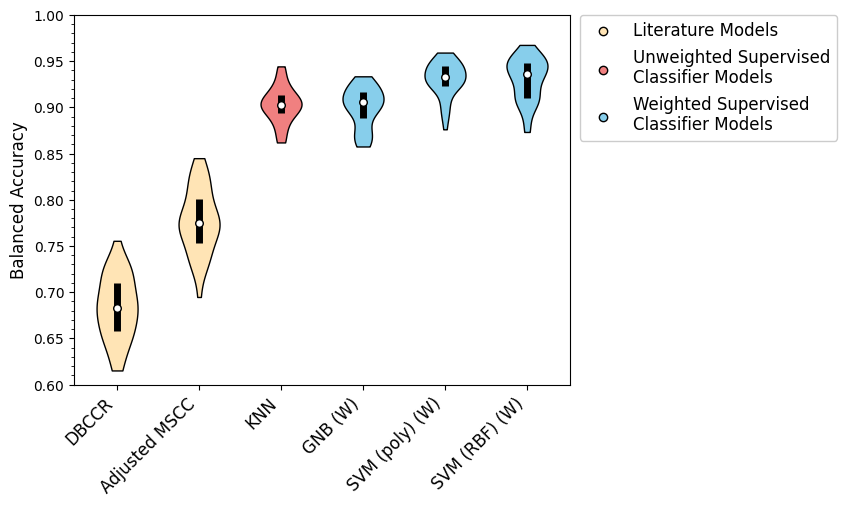

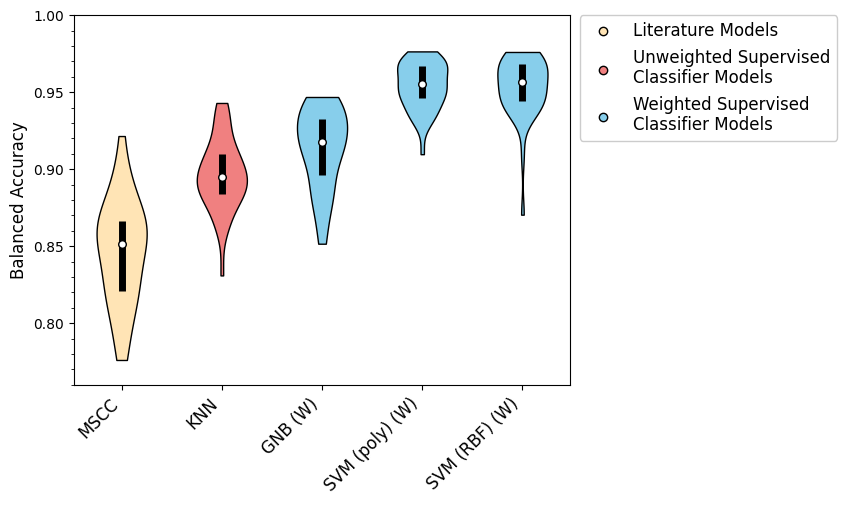

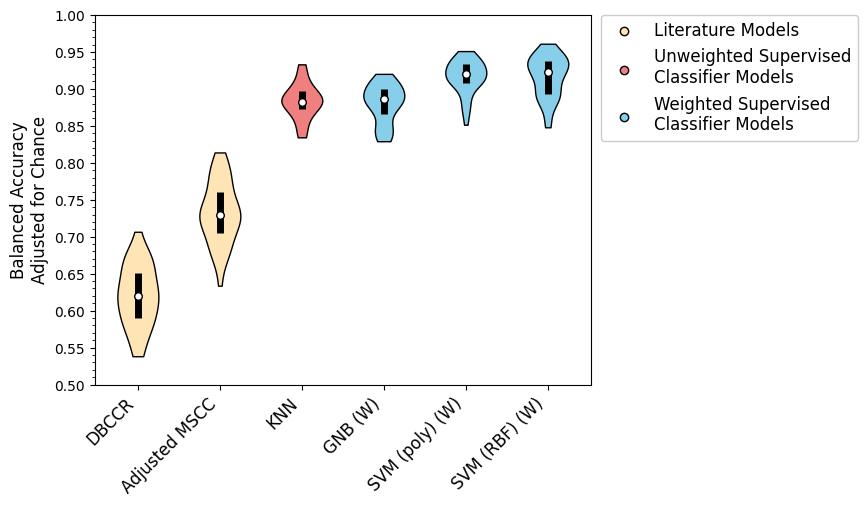

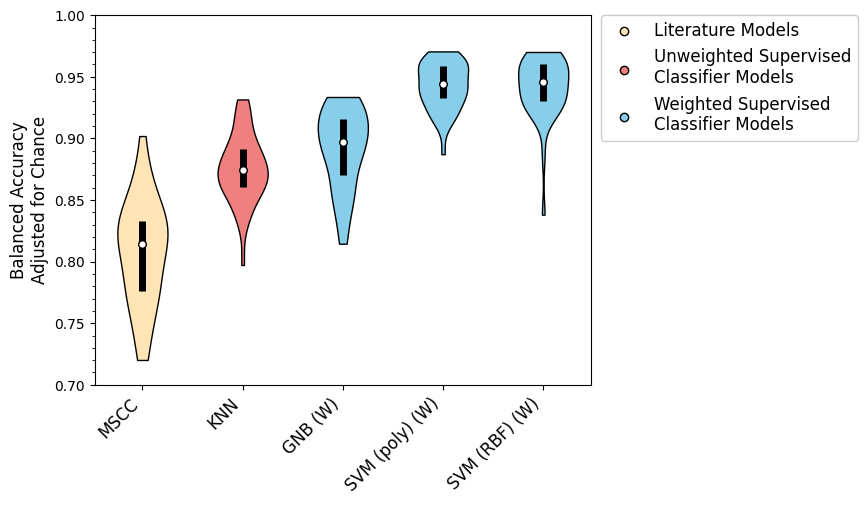

In [16]:
figsize=(10,4.8) # width, height

def ru_bool(x):
    return 'R-U' in x or ('MSCC' in x and 'Adjusted' not in x)

hide_unweighted = True

for plot_choice in plot_type:
    for acc_type in data_dict.keys():
        
        if acc_type == 'raw':
            ylabel = 'Accuracy'

            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_acc
            # colours_to_use = [zero_rule_colour] + boxplot_colors
            for x in accuracies_dict: data_to_use[x] = accuracies_dict[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy'
            data_to_use = balanced_accuracies_dict
            # colours_to_use = boxplot_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict
            # colours_to_use = boxplot_colors
        
        if hide_unweighted and acc_type!='raw':
            data_to_use = {x:data_to_use[x] for x in data_to_use if '(U)' not in x}

        for ru_defs in [False,True]:

            if ru_defs:
                data_to_use_ru = {x.replace(' (R-U)',''):data_to_use[x] for x in data_to_use.keys() if ru_bool(x) or x == 'Zero Rule'}
            else:
                data_to_use_ru = {x:data_to_use[x] for x in data_to_use.keys() if not ru_bool(x)}

            boxplot_colors = [model_colour(x) for x in data_to_use_ru.keys()]

            fig, ax = plot_type[plot_choice](data_to_use_ru,
                                             ylabel=ylabel,
                                             colours=boxplot_colors,)
            
            set_y_ticks(data_to_use_ru,ax,major_ticks_interval=0.05,minor_ticks_interval=0.01,rounding=2)

            if acc_type == 'raw':
                ax.scatter([], [], c=zero_rule_colour,  label='Zero Rule', edgecolors='k')

            for c in boxplot_colors_dict:
                if boxplot_colors_dict[c] in boxplot_colors:
                    ax.scatter([], [], c=boxplot_colors_dict[c], label=c, edgecolors='k')
            
            title = f'Comparison of the {ylabel.replace('\n',' ')} of Assignment\nbetween Literature and Classifier Models'
            fig_path = f'{comparison_plots_output_folder}\\comparison_{plot_choice}_{acc_type}'
            if ru_defs:
                fig_path += '_rivas-ubach'
                title += '\n(R-U Definitions)'

            if show_title:
                ax.set_title(title,fontsize=16)

            ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
            
            fig.savefig(f'{fig_path}.svg',dpi=600, facecolor='#fff', bbox_inches='tight')

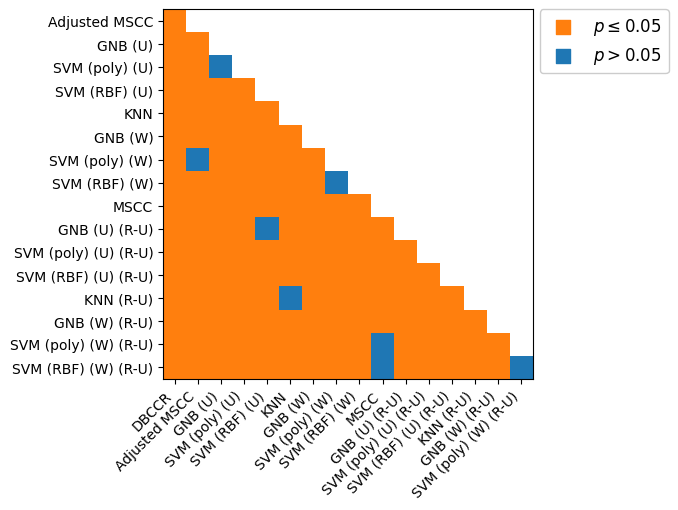

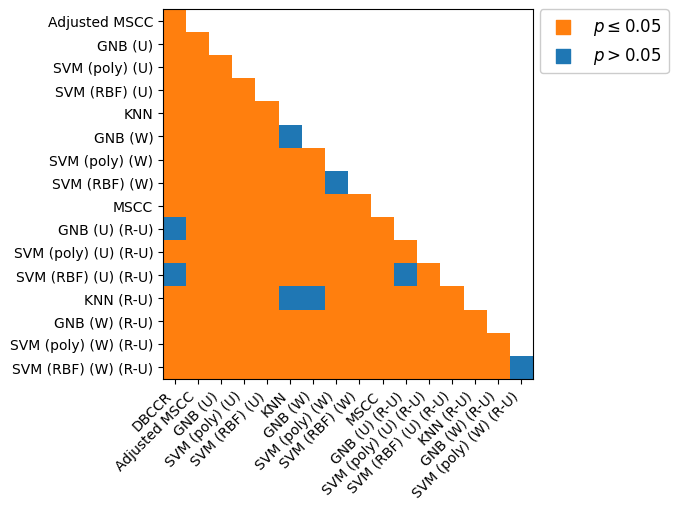

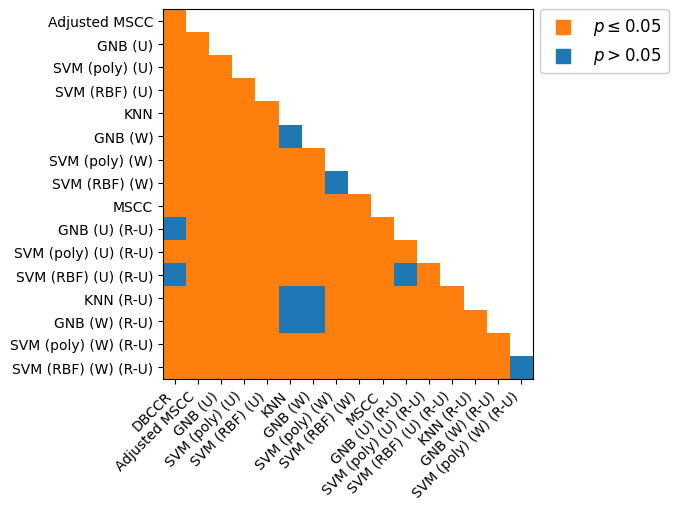

In [17]:
threshold = 0.05

for combo in [[accuracies_dict,'Correlation Matrix of\nthe Model Accuracies','correlation_matrix_accuracies'],
              [balanced_accuracies_dict,'Correlation Matrix of\nthe Balanced Model Accuracies','correlation_matrix_balanced_accuracies'],
              [chance_balanced_accuracies_dict,'Correlation Matrix of\nthe Chance Balanced Model Accuracies','correlation_matrix_chance_balanced_accuracies'],]:

    correlation_matrix(combo[0], threshold=threshold,
                       title=combo[1] if show_title else None,
                       savepath=f'{comparison_plots_output_folder}\\{combo[2]}.svg')

## Now fit models by adding another category: PAHs.

In [18]:
df_with_pahs_path = 'data\\csv_files\\new_vk_areas_with_pahs.csv'

In [19]:
df_with_pahs = pd.read_csv(df_with_pahs_path)

In [20]:
X_with_pahs_2d = df_with_pahs[columns_2d].to_numpy()
X_with_pahs_3d = df_with_pahs[columns_3d].to_numpy()

y_with_pahs = df_with_pahs['category'].to_numpy()
weights_with_pahs = df_with_pahs['weights'].to_numpy() if weighted else None

In [21]:
clf_models_with_pahs = {
    'GNB (W)': CalibratedClassifierCV(GaussianNB()),
    'SVM (poly) (W)': CalibratedClassifierCV(SVC(kernel="poly", **mlcf.svm_poly_param_3d_with_PAHs)),
    'SVM (RBF) (W)': CalibratedClassifierCV(SVC(kernel="rbf", **mlcf.svm_rbf_param_3d_with_PAHs)),
}

clf_models_with_pahs_unweighted = {x.replace('(W)','(U)'):clf_models_with_pahs[x] for x in clf_models_with_pahs}
clf_models_with_pahs_unweighted['KNN'] = mlcf.knn_pipeline(mlcf.knn_param_3d_with_PAHs)

models_with_pahs_list = list(clf_models_with_pahs_unweighted.keys()) + list(clf_models_with_pahs.keys())

In [22]:
accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
balanced_accuracies_dict_with_pahs = {name: [] for name in models_with_pahs_list}
zero_rule_with_pahs_acc = []

repeats = 40

columns = columns_3d

for n in range(repeats):
    print(f'Accuracy test iteration {n+1} of {repeats}')

    zero_rule_class = np.unique(y_rdm_test)[np.argmax([len(np.where(y_rdm_test==cat)[0]) for cat in np.unique(y_rdm_test)])]
    zero_rule_with_pahs_acc.append(accuracy_score(y_true=y_rdm_test,
                                                  y_pred=[zero_rule_class]*len(y_rdm_test),
                                                  normalize=True))

    X_rdm_train, X_rdm_test, y_rdm_train, y_rdm_test, \
    weights_rdm_train, weights_rdm_test = mlcf.train_test(X_with_pahs_3d, y_with_pahs,random_state=None)

    for modeltype in [clf_models_with_pahs,clf_models_with_pahs_unweighted]:

        for model in modeltype:

            print(f'{n+1}/{repeats}\tTesting model: {model}')

            fit_args = dict(X=X_rdm_train, y=y_rdm_train)
            if weighted and modeltype == clf_models_with_pahs: fit_args['sample_weight'] = weights_rdm_train

            y_pred = modeltype[model].fit(**fit_args).predict(X_rdm_test)

            for accuracy_type in [[accuracy_score, dict(normalize=True), accuracies_dict_with_pahs],
                                  [balanced_accuracy_score, dict(sample_weight=weights_rdm_test if weighted else None), balanced_accuracies_dict_with_pahs]]:

                acc = accuracy_type[0](y_true=y_rdm_test,
                                       y_pred=y_pred,
                                       **accuracy_type[1])
                accuracy_type[2][model].append(acc)

            print(f'\t\taccuracy: {accuracies_dict_with_pahs[model][-1]}, balanced accuracy: {balanced_accuracies_dict_with_pahs[model][-1]}')


Accuracy test iteration 1 of 40
1/40	Testing model: GNB (W)
		accuracy: 0.7664473684210527, balanced accuracy: 0.9015024983996575
1/40	Testing model: SVM (poly) (W)
		accuracy: 0.8865131578947368, balanced accuracy: 0.8986045315001496
1/40	Testing model: SVM (RBF) (W)
		accuracy: 0.8980263157894737, balanced accuracy: 0.9270643129598816
1/40	Testing model: GNB (U)
		accuracy: 0.9161184210526315, balanced accuracy: 0.6376656058965029
1/40	Testing model: SVM (poly) (U)
		accuracy: 0.9103618421052632, balanced accuracy: 0.6479010307315674
1/40	Testing model: SVM (RBF) (U)
		accuracy: 0.9078947368421053, balanced accuracy: 0.6399247261289673
1/40	Testing model: KNN
		accuracy: 0.9506578947368421, balanced accuracy: 0.9031887504137333
Accuracy test iteration 2 of 40
2/40	Testing model: GNB (W)
		accuracy: 0.7615131578947368, balanced accuracy: 0.9227664207520079
2/40	Testing model: SVM (poly) (W)
		accuracy: 0.8856907894736842, balanced accuracy: 0.9556216839218649
2/40	Testing model: SVM (

KeyboardInterrupt: 

In [ ]:
chance_balanced_accuracies_dict_with_pahs = {}
for key in balanced_accuracies_dict_with_pahs:
    number_of_categories = len(np.unique(y_with_pahs))

    chance = 1 / number_of_categories

    chance_balanced_accuracies_dict_with_pahs[key] = [(acc-chance)/(1 - chance) for acc in balanced_accuracies_dict_with_pahs[key] ]

comparison_with_pahs_df = pd.DataFrame({
    'model':[model.replace('$', '').replace('\\', '') for model in clf_models_with_pahs.keys()],
    'mean_accuracy':[np.mean(accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'std_accuracy':[np.std(accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'median_accuracy':[np.median(accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'mean_balanced_accuracy':[np.mean(balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'std_balanced_accuracy':[np.std(balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'median_balanced_accuracy':[np.median(balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'mean_chance_balanced_accuracy':[np.mean(chance_balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'std_chance_balanced_accuracy':[np.std(chance_balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
    'median_chance_balanced_accuracy':[np.median(chance_balanced_accuracies_dict_with_pahs[model]) for model in clf_models_with_pahs.keys()],
})

comparison_with_pahs_df.to_csv('data\\csv_files\\model_performance_comparison_with_pahs.csv', index=False)

In [ ]:
boxplot_with_pahs_colors = []

for model in models_with_pahs_list:
    if model in clf_models_with_pahs:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Weighted Supervised\nClassifier Models'])
    elif model in clf_models_with_pahs_unweighted:
        boxplot_with_pahs_colors.append(boxplot_colors_dict['Unweighted Supervised\nClassifier Models'])
zero_rule_colour = 'grey'

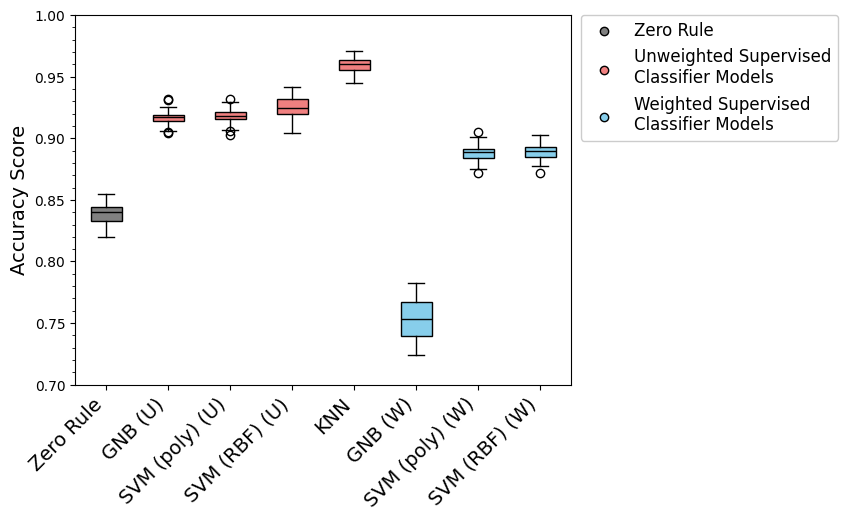

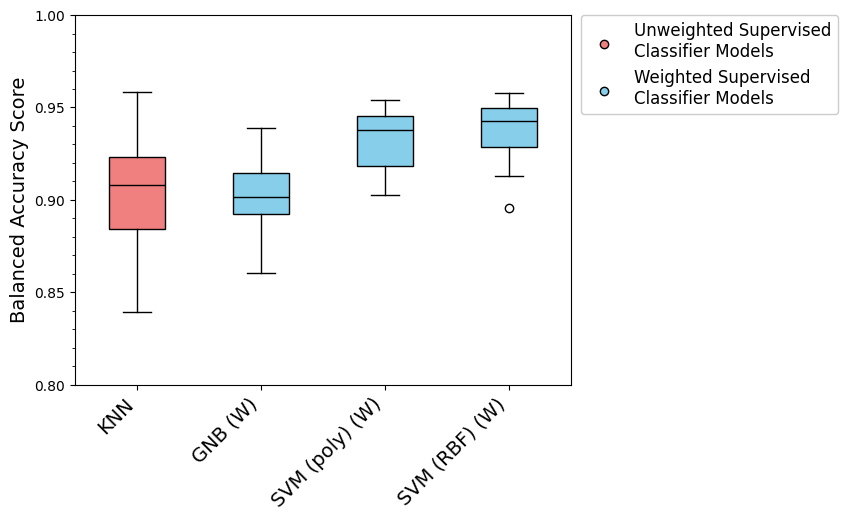

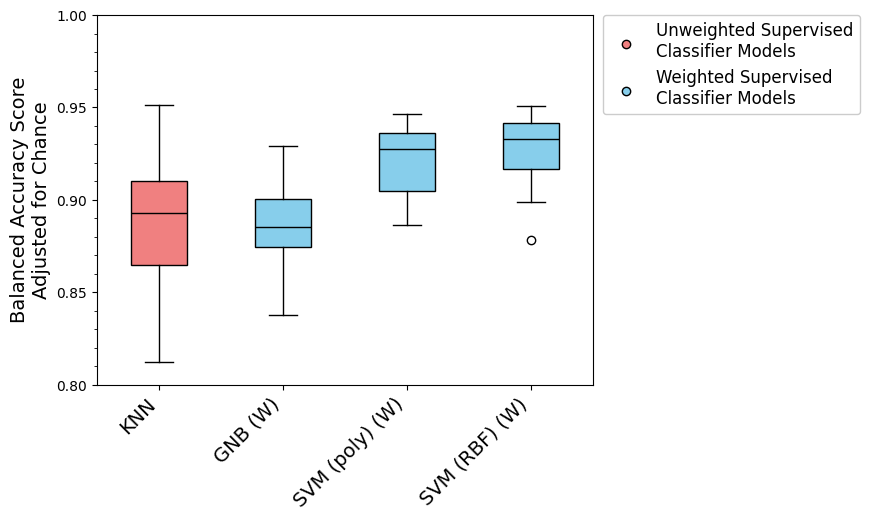

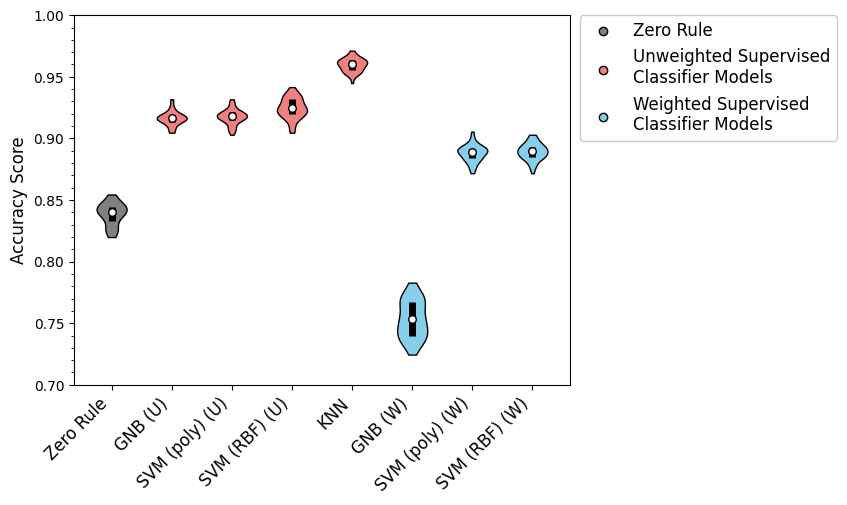

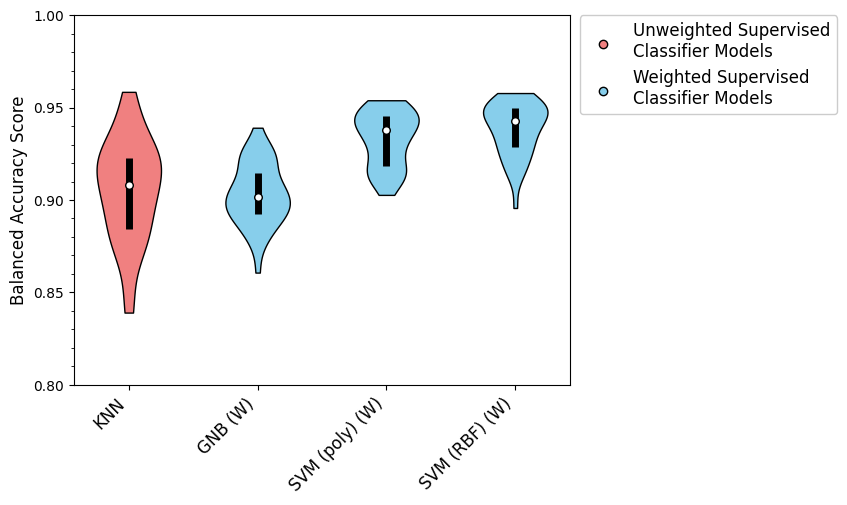

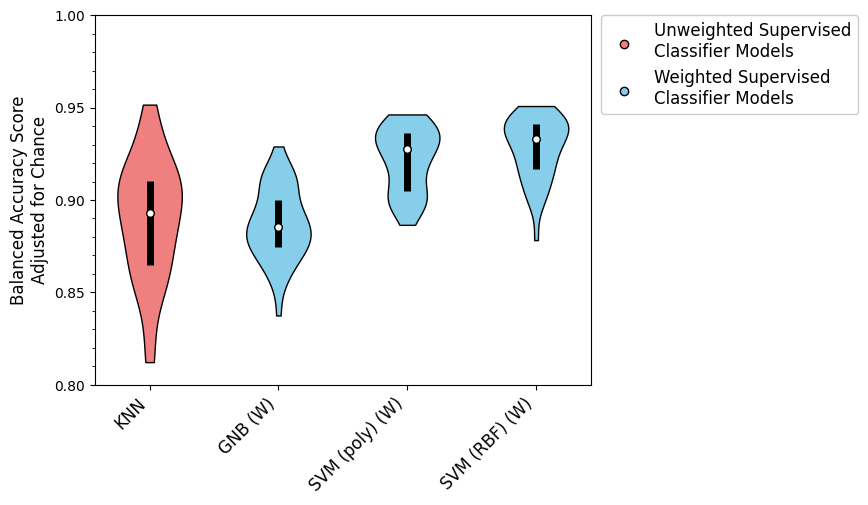

In [ ]:
data_dict_with_pahs = {'raw':accuracies_dict_with_pahs,
                       'balanced':balanced_accuracies_dict_with_pahs,
                       'chance':chance_balanced_accuracies_dict_with_pahs}

figsize=None#(10,4.8)

hide_unweighted = True

for plot_choice in plot_type:
    for acc_type in data_dict_with_pahs.keys():
        if acc_type == 'raw':
            ylabel = 'Accuracy Score'

            data_to_use = {}
            data_to_use['Zero Rule'] = zero_rule_with_pahs_acc
            colours_to_use = [zero_rule_colour] + boxplot_with_pahs_colors
            
            for x in accuracies_dict_with_pahs: data_to_use[x] = accuracies_dict_with_pahs[x]
        
        elif acc_type == 'balanced':
            ylabel = 'Balanced Accuracy Score'
            data_to_use = balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors
        
        elif acc_type == 'chance':
            ylabel = 'Balanced Accuracy Score\nAdjusted for Chance'
            data_to_use = chance_balanced_accuracies_dict_with_pahs
            colours_to_use = boxplot_with_pahs_colors

        if hide_unweighted and acc_type != 'raw':
            data_to_use = {x:data_to_use[x] for x in data_to_use if '(U)' not in x}
            colours_to_use = [model_colour(x) for x in data_to_use]

        fig, ax = plot_type[plot_choice](data_to_use,
                                         ylabel=ylabel,
                                         colours=colours_to_use,
                                         figsize=figsize,
                                         savepath=f'{comparison_plots_output_folder}\\comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                                         )
        
        set_y_ticks(data_to_use,ax,major_ticks_interval=0.05,
                    minor_ticks_interval=0.01,rounding=2)
        
        if acc_type == 'raw':
            ax.scatter([], [], c=zero_rule_colour,  label='Zero Rule', edgecolors='k')

        for c in boxplot_colors_dict:
            if boxplot_colors_dict[c] in boxplot_with_pahs_colors:
                ax.scatter([], [], c=boxplot_colors_dict[c], label=c, edgecolors='k')
        
        if show_title:
            ax.set_title(f'Comparison of the {ylabel.replace('\n',' ')} of Assignment\nbetween Classifier Models Including PAHs' if show_title else None,
                         fontsize=16)

        ax.legend(framealpha=1,bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0,fontsize=12)
        fig.savefig(f'{comparison_plots_output_folder}\\comparison_with_pahs_{plot_choice}_{acc_type}.svg',
                    dpi=600, facecolor='#fff', bbox_inches='tight')

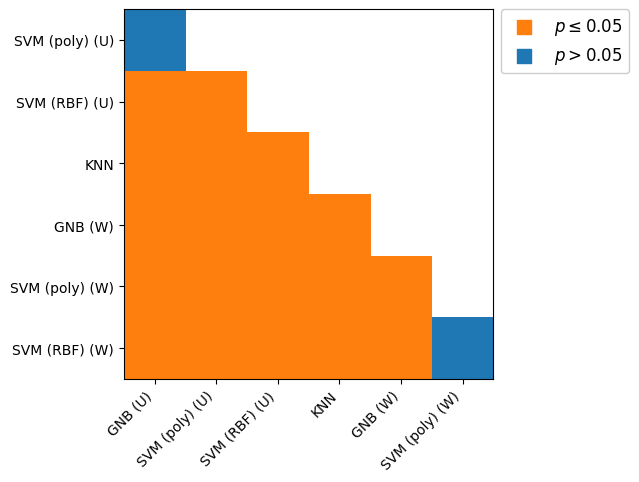

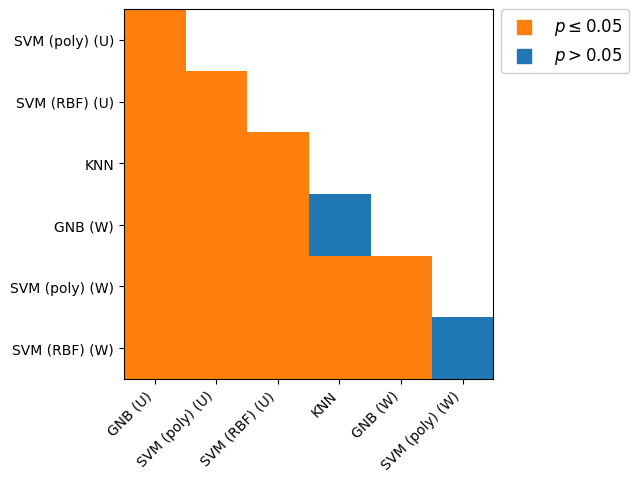

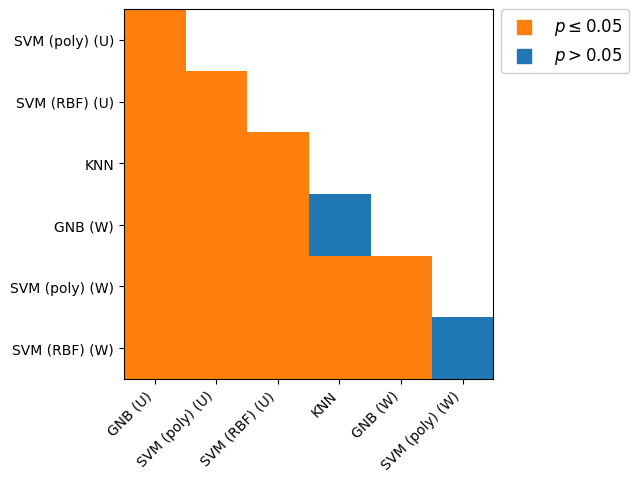

In [ ]:
threshold = 0.05

for combo in [[accuracies_dict_with_pahs,'Correlation Matrix of\nthe Model Accuracies Including PAHs','correlation_matrix_accuracies_with_pahs'],
              [balanced_accuracies_dict_with_pahs,'Correlation Matrix of\nthe Balanced Model Accuracies Including PAHs','correlation_matrix_balanced_accuracies_with_pahs'],
              [chance_balanced_accuracies_dict_with_pahs,'Correlation Matrix of\nthe Chance Balanced Model Accuracies Including PAHs','correlation_matrix_chance_balanced_accuracies_with_pahs'],]:

    correlation_matrix(combo[0], threshold=threshold,
                       title=combo[1] if show_title else None,
                       savepath=f'{comparison_plots_output_folder}\\{combo[2]}.svg')